# Module 04 - Tokenization

Use this notebook as the working space for the Module 04 exercises.

1. Read the lesson page (`docs/modules/04-tokenizer.md`).
2. Open this notebook with `.venv/bin/python scripts/open_notebook.py 04`.
3. Answer the `Question:` / `Answer:` cells below.
4. When you're ready, ask a coding agent to grade your notebook.

Partial work is fine. Blank `Answer: ""` strings are skipped, not counted wrong. If you'd like a hint instead of a grade, write the request inline in the answer string and the agent will tutor first.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt

from g2c.artifacts import find_repo_root
from g2c.tokenizer import BPETokenizer, COURSE_SPECIAL_TOKENS

## Before the Notebook

Use the tests to implement the tokenizer pieces first. The notebook assumes `_get_pair_counts`, `_merge`, `train_step`, `encode`, and `decode` are available as you progress. The scaffolded `train()` loop, Rust-backed `train_fast()`/`encode_fast()`, and tokenizer save/load helpers are implemented for you.

In [2]:
"Run from the terminal: .venv/bin/python -m pytest tests/test_tokenizer.py -x"
"Question: Which tokenizer test is the next one failing, and what implementation does it point at?"
"Answer: "

'Answer: '

## Exercise 1 - Pair Counts and Merge

These two helpers are the BPE algorithm's core data-structure operations. Predict the outputs before running your implementation.

In [3]:
"Question: What adjacent-pair counts should [1, 2, 1, 2, 3] produce?"
"Answer: "

"Question: Why does a list of length n have only n - 1 adjacent pairs?"
"Answer: "

"Question: What should _merge([1, 1, 1], (1, 1), 99) return, and why?"
"Answer: "

'Answer: '

In [4]:
pair_count_example = [1, 2, 1, 2, 3]
merge_example = [1, 1, 1]

print(BPETokenizer._get_pair_counts(pair_count_example))
print(BPETokenizer._merge(merge_example, (1, 1), 99))

{(1, 2): 2, (2, 1): 1, (2, 3): 1}
[99, 1]


## Exercise 2 - Train BPE on a Tiny Corpus

Train on a very small repeated string first. Call one `train_step()` by hand, then let scaffolded `train()` repeat that step until the target vocabulary size is reached. This makes the learned merges easy to inspect by hand.

In [5]:
tiny_corpus = "the the the"

"Question: In the initial byte sequence for 'the the the', which adjacent pair should be most frequent?"
"Answer: "

"Question: If the target vocab size is 259, how many merges should be learned from a fresh tokenizer?"
"Answer: "

"Question: Why should the new token IDs start at 256?"
"Answer: "

'Answer: '

In [6]:
step_tok = BPETokenizer()
step_ids = list(tiny_corpus.encode("utf-8"))

print("one step:", step_tok.train_step(step_ids, new_id=len(step_tok.vocab)))
print("merges after one step:", step_tok.merges)
print("learned vocab after one step:", {i: step_tok.vocab[i] for i in range(256, len(step_tok.vocab))})


def print_bpe_progress(info: dict) -> None:
    print(
        f"step {info['steps']} | "
        f"vocab {info['vocab_size']}/{info['target_vocab_size']} | "
        f"last token {info['last_token_repr']} | "
        f"tokens {info['tokens']} | "
        f"last merge count {info['last_merge_count']} | "
        f"elapsed {info['elapsed_seconds']:.3f}s"
    )


tiny_tok = BPETokenizer()
tiny_tok.train(tiny_corpus, vocab_size=259, progress_callback=print_bpe_progress, progress_every=1)
print("merges:", tiny_tok.merges)
print("learned vocab:", {i: tiny_tok.vocab[i] for i in range(256, len(tiny_tok.vocab))})
assert len(tiny_tok.vocab) == 259

one step: ([256, 101, 32, 256, 101, 32, 256, 101], (116, 104), 3)
merges after one step: {(116, 104): 256}
learned vocab after one step: {256: b'th'}
step 1 | vocab 257/259 | last token 'th' | tokens 8 | last merge count 3 | elapsed 0.000s
step 2 | vocab 258/259 | last token 'the' | tokens 5 | last merge count 3 | elapsed 0.000s
step 3 | vocab 259/259 | last token 'the ' | tokens 3 | last merge count 2 | elapsed 0.000s
merges: {(116, 104): 256, (256, 101): 257, (257, 32): 258}
learned vocab: {256: b'th', 257: b'the', 258: b'the '}


## Exercise 3 - Encode, Decode, and Round Trip

A byte-level tokenizer should round-trip any UTF-8 text, including text with characters that were not in the training corpus.

In [7]:
"Question: Why can a byte-level tokenizer encode text it never saw during training?"
"Answer: "

"Question: During encode, why should the learned merge with the lowest new ID get priority?"
"Answer: "

"Question: What property of vocab entries makes decode lossless?"
"Answer: "

'Answer: '

In [8]:
roundtrip_texts = [
    "the theater there",
    "héllo wörld",
    "unseen text 12345 🌍",
]

roundtrip_tok = BPETokenizer()
roundtrip_tok.train("the quick brown fox jumps over the lazy dog " * 20, vocab_size=300)
for text in roundtrip_texts:
    ids = roundtrip_tok.encode(text)
    decoded = roundtrip_tok.decode(ids)
    print(text, "->", ids, "->", decoded)
    assert decoded == text

the theater there -> [258, 257, 97, 116, 101, 114, 32, 257, 114, 101] -> the theater there
héllo wörld -> [104, 195, 169, 108, 108, 111, 32, 119, 195, 182, 114, 108, 100] -> héllo wörld
unseen text 12345 🌍 -> [117, 110, 115, 101, 101, 110, 32, 116, 101, 120, 116, 32, 49, 50, 51, 52, 53, 32, 240, 159, 140, 141] -> unseen text 12345 🌍


## Exercise 4 - Special Tokens as Atomic Markers

Special tokens are reserved control strings. Later modules use them for document boundaries, chat roles, and tool-call events. They should encode as one token ID each, not as ordinary BPE pieces.

In [9]:
"Question: Why should <|assistant|> be one atomic ID instead of ordinary text pieces?"
"Answer: "

"Question: If a tokenizer reserves 8 special tokens, where should the first learned BPE merge ID start?"
"Answer: "

'Answer: '

In [10]:
special_tok = BPETokenizer.with_course_special_tokens()
chat_text = "<|user|>\nHello<|end|><|assistant|>\nHi!<|end|>"
chat_ids = special_tok.encode(chat_text)

print("course special tokens:")
for token in COURSE_SPECIAL_TOKENS:
    print(token, "->", special_tok.special_to_id[token])

print("\nencoded chat ids:", chat_ids)
assert special_tok.special_to_id["<|user|>"] in chat_ids
assert special_tok.special_to_id["<|assistant|>"] in chat_ids
assert chat_ids.count(special_tok.special_to_id["<|end|>"]) == 2
assert special_tok.decode(chat_ids) == chat_text
assert special_tok.base_vocab_size == 256 + len(COURSE_SPECIAL_TOKENS)

course special tokens:
<|endoftext|> -> 256
<|system|> -> 257
<|user|> -> 258
<|assistant|> -> 259
<|tool_call|> -> 260
<|tool_result|> -> 261
<|end|> -> 262
<|pad|> -> 263

encoded chat ids: [258, 10, 72, 101, 108, 108, 111, 262, 259, 10, 72, 105, 33, 262]


## Exercise 5 - Vocab Size vs Compression

Train several tokenizers at different vocab sizes and compare how many tokens they use for the same passage. The default corpus below is small for quick iteration; replace it with a larger text file for the full experiment.

In [11]:
def load_tokenizer_corpus(path: str | Path | None = None) -> str:
    """Load a text corpus, or use a small built-in corpus for smoke runs."""
    if path is not None:
        return Path(path).read_text(encoding="utf-8")

    paragraph = """
    The quick brown fox jumps over the lazy dog. The theater is there,
    and the theory of tokenization is that frequent text fragments become
    shorter symbols. In a small corpus, common words repeat; in a large corpus,
    BPE discovers useful subwords like ing, tion, the, and spaces before words.
    """
    return "\n".join(line.strip() for line in paragraph.splitlines() if line.strip()) * 40


corpus = load_tokenizer_corpus()
passage = corpus[:300]
print("corpus characters:", len(corpus))
print("passage characters:", len(passage))

corpus characters: 11520
passage characters: 300


In [12]:
"Question: What do you predict will happen to token count as vocab size increases?"
"Answer: "

"Question: Why might the improvement show diminishing returns?"
"Answer: "

"Question: What is the tradeoff of using a very large vocabulary in a real model?"
"Answer: "

'Answer: '

In [13]:
def train_and_measure(corpus: str, passage: str, vocab_sizes: list[int]) -> list[dict]:
    """Train tokenizers and return compression statistics.

    Each result row should contain:
      - vocab_size_requested
      - vocab_size_actual
      - token_count
      - byte_count
      - chars_per_token
      - tokenizer
    """
    rows = []
    for vocab_size in vocab_sizes:
        # TODO: create BPETokenizer()
        # TODO: train it on corpus at vocab_size
        # TODO: encode passage
        # TODO: append a result dict with the fields listed above
        raise NotImplementedError("measure compression at each vocab size")
    return rows

In [14]:
# Use small vocab sizes for the built-in corpus. For a larger corpus, try [256, 1024, 8192].
vocab_sizes = [256, 300, 400]

compression_rows = train_and_measure(corpus, passage, vocab_sizes)
for row in compression_rows:
    printable = {k: v for k, v in row.items() if k != "tokenizer"}
    print(printable)

plt.plot(
    [row["vocab_size_actual"] for row in compression_rows],
    [row["token_count"] for row in compression_rows],
    marker="o",
)
plt.xlabel("actual vocab size")
plt.ylabel("tokens in fixed passage")
plt.title("BPE compression improves as vocab grows")
plt.show()

NotImplementedError: measure compression at each vocab size

## Exercise 6 - Inspect Learned Tokens

Print early and late learned vocab entries. Early learned IDs should usually be short, high-frequency byte patterns. Later learned IDs tend to be longer and more corpus-specific.

In [15]:
"Question: Why should token IDs just above 255 usually represent very common patterns?"
"Answer: "

"Question: What kind of learned token would count as corpus-specific rather than generally useful?"
"Answer: "

'Answer: '

In [16]:
def token_bytes_display(token_bytes: bytes) -> str:
    """Display bytes as text when possible, with escapes for non-printing bytes."""
    return token_bytes.decode("utf-8", errors="backslashreplace")


def learned_vocab_window(tok: BPETokenizer, n: int = 20) -> tuple[list[tuple[int, str]], list[tuple[int, str]]]:
    """Return first and last n learned vocab entries as printable pairs."""
    # TODO: collect learned IDs, i.e. IDs >= tok.base_vocab_size
    # TODO: return first n and last n entries as (id, display_text) tuples
    raise NotImplementedError("inspect learned vocab entries")

In [17]:
largest_tok = compression_rows[-1]["tokenizer"]
first_tokens, last_tokens = learned_vocab_window(largest_tok, n=20)

print("First learned tokens:")
for token_id, text in first_tokens:
    print(token_id, repr(text))

print("\nLast learned tokens:")
for token_id, text in last_tokens:
    print(token_id, repr(text))

NameError: name 'compression_rows' is not defined

In [18]:
"Question: Name two early learned tokens and explain why they are plausible frequent patterns."
"Answer: "

"Question: Name one late learned token and explain what makes it more specific."
"Answer: "

'Answer: '

## Exercise 7 - Pre-Tokenization Demo

GPT-2-style tokenizers split text before BPE so merges do not freely cross every boundary. This demo uses a very simple whitespace/non-whitespace split so you can see how the candidate pair counts change.

In [19]:
"Question: Why might merging across whitespace create less useful tokens?"
"Answer: "

"Question: What would you compare before and after adding pre-tokenization?"
"Answer: "

'Answer: '

In [20]:
import re
from collections import Counter


def simple_pretokenize(text: str) -> list[str]:
    """Split into whitespace spans and non-whitespace spans."""
    return re.findall(r"\s+|\S+", text)


def pair_counts_within_pretokens(text: str) -> Counter[tuple[int, int]]:
    """Count adjacent byte pairs without crossing pre-token boundaries."""
    counts: Counter[tuple[int, int]] = Counter()
    for piece in simple_pretokenize(text):
        counts.update(BPETokenizer._get_pair_counts(list(piece.encode("utf-8"))))
    return counts


pretok_text = "the theater there and the theory"
raw_counts = Counter(BPETokenizer._get_pair_counts(list(pretok_text.encode("utf-8"))))
pretok_counts = pair_counts_within_pretokens(pretok_text)

print("pre-tokens:", simple_pretokenize(pretok_text))
print("raw top pairs:", raw_counts.most_common(8))
print("pre-tokenized top pairs:", pretok_counts.most_common(8))
print("\nNotice that pre-tokenized counts never include a pair crossing from the end of one word into the next span.")

pre-tokens: ['the', ' ', 'theater', ' ', 'there', ' ', 'and', ' ', 'the', ' ', 'theory']
raw top pairs: [((116, 104), 5), ((104, 101), 5), ((32, 116), 4), ((101, 32), 3), ((101, 114), 2), ((101, 97), 1), ((97, 116), 1), ((116, 101), 1)]
pre-tokenized top pairs: [((116, 104), 5), ((104, 101), 5), ((101, 114), 2), ((101, 97), 1), ((97, 116), 1), ((116, 101), 1), ((114, 101), 1), ((97, 110), 1)]

Notice that pre-tokenized counts never include a pair crossing from the end of one word into the next span.


## Mini Milestone - Train Reusable Tokenizer Artifacts

The exercises above teach the BPE algorithm. This section turns that implementation into reusable course artifacts: trained tokenizers, small encoded inspection samples, and views that make the learned tokenization visible. Run this after the tokenizer tests pass.

Artifacts are written under `artifacts/tokenizers/`. Later modules can load the saved tokenizer JSON instead of retraining BPE from scratch; full pre-tokenized corpora are separate later artifacts. Artifact tokenizers reserve the course special tokens by default so later chat/tool modules can reuse the same IDs. The package code in `g2c.artifacts` handles path detection, corpus loading, artifact detection, manifests, and save/load; this notebook keeps the corpus choices and visual inspection.

In [21]:
from g2c.artifacts import (
    TokenizerArtifactConfig,
    tokenizer_artifacts_root,
)
from g2c.notebook_extras.tokenizer import run_and_inspect_tokenizer_artifact

repo_root = find_repo_root()
tokenizer_artifact_root = tokenizer_artifacts_root(repo_root)
FORCE_RETRAIN_TOKENIZERS = False
print("tokenizer artifacts:", tokenizer_artifact_root.relative_to(repo_root))

tokenizer artifacts: artifacts/tokenizers


### TinyShakespeare Tokenizer

TinyShakespeare is small enough to train with the Python scaffolded BPE loop. That is useful here: the saved artifact comes from the same `train_step()` logic you implemented, and the progress display shows each learned token as the vocabulary grows.

ShakespeareTokenizer: vocab `2,048/2,048` | steps `1,784` | tokens `321,341` | last token `'might '` | last count `46` | elapsed `131.4s`

saved ShakespeareTokenizer: 321,341 sample token IDs
ShakespeareTokenizer
trainer: python-scaffold
vocab size: 2048
sample token count: 321341
encoded sample chars: 1000000
chars/token: 3.112

Sample text:
'he bloody king.\nAnd here he comes.\nAll hail, my sovereign liege!\n\nKING RICHARD III:\nKind Tyrrel, am I happy in thy news?\n\nTYRREL:\nIf to have done the thing you gave in charge\nBeget your happiness, be happy then,\nFor it is done, my lord.\n\nKING RICHARD III:\nBut didst thou see them dead?\n\nTYRREL:\nI did, my lord.\n\nKING RICHARD III:\nAnd buried, gentle Tyrrel?\n\nTY'

Token strings for sample:
['he ', 'bloo', 'dy ', 'king', '.\\n', 'And ', 'here ', 'he ', 'com', 'es', '.\\n', 'A', 'll ', 'ha', 'il', ', my ', 'sovereign', ' ', 'lie', 'ge', '!\\n\\n', 'KING RICHARD III', ':\\n', 'K', 'ind ', 'Ty', 'r', 'rel', ', ', 'am', ' I ', 'happy ', 'in', ' thy ', 'new', 's', '?\\n\\n', 'T', 'Y', 'R', 'R', 'EL', ':\\nIf', ' to ', 'have ', 'done ', 'the ', 'thing ', 'you', ' g', 'a', 

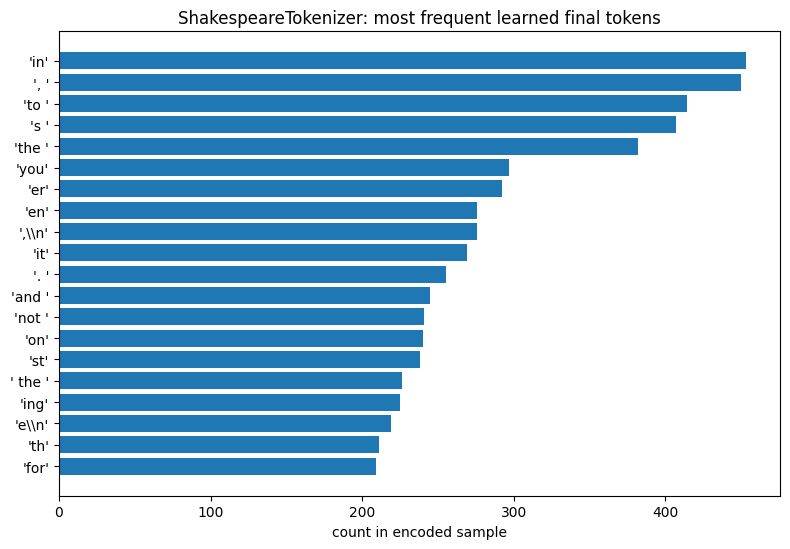

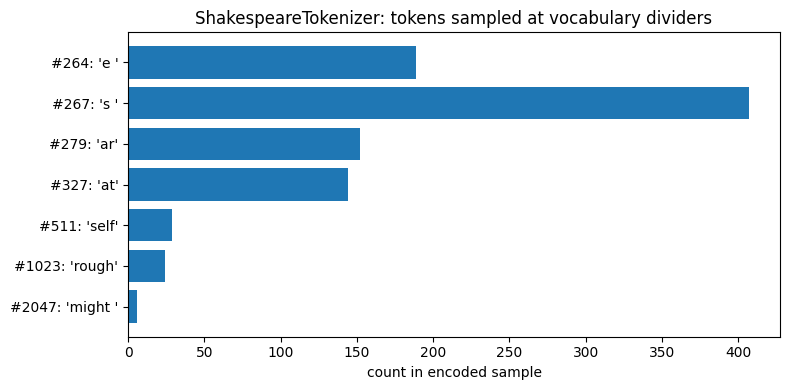

In [22]:
shakespeare_config = TokenizerArtifactConfig(
    name="ShakespeareTokenizer",
    source="tinyshakespeare",
    vocab_size=2048,
    max_chars=1_000_000,
    use_fast=False,
    notes="Small reusable tokenizer for ShakespeareLM smoke and scaling runs.",
)

shakespeare_artifact = run_and_inspect_tokenizer_artifact(
    shakespeare_config,
    repo_root=repo_root,
    force=True,
)

### TinyStories Tokenizer

TinyStories is much larger, so this cell uses `train_fast()`. The fast path uses the optimized Rust `tokenizers` library, streams the text to that trainer in chunks, then copies the learned merges back into the same `BPETokenizer.merges` and `BPETokenizer.vocab` tables. Functionally it is the same BPE artifact; it just avoids spending notebook time on repeated Python scans.

Run `./datasets.sh --tiny` for the 100MB starter TinyStories file or `./datasets.sh tinystories` for the full local corpus.

loaded StoryTokenizer: 192,397 sample token IDs
StoryTokenizer
trainer: rust-tokenizers
vocab size: 4096
sample token count: 192397
encoded sample chars: 1000000
chars/token: 5.198

Sample text:
" top. Lily couldn't wait to try it. She took a big bite, but it was too spicy for her. She didn't like it at all.\nLily started to feel sick and her mommy had to take her to the hospital. The doctor said that the spicy frosting made her very sick and she had to stay in the hospital for a long time. Lily learned that sometimes things that look and smell good c"

Token strings for sample:
[' ', 'top', '. Lily ', "couldn't wait to ", 'try ', 'it. She ', 'took ', 'a big ', 'bit', 'e, but ', 'it was too ', 'spicy ', 'for ', 'her. She ', "didn't ", 'like ', 'it ', 'at ', 'all', '.\\nLily ', 'started to feel ', 's', 'ic', 'k and ', 'her mommy ', 'had to ', 'take ', 'her ', 'to the ', 'ho', 'sp', 'it', 'al', '. The ', 'doctor ', 'said ', 'that the ', 'spicy ', 'fro', 'st', 'ing ', 'made her ', 'very '

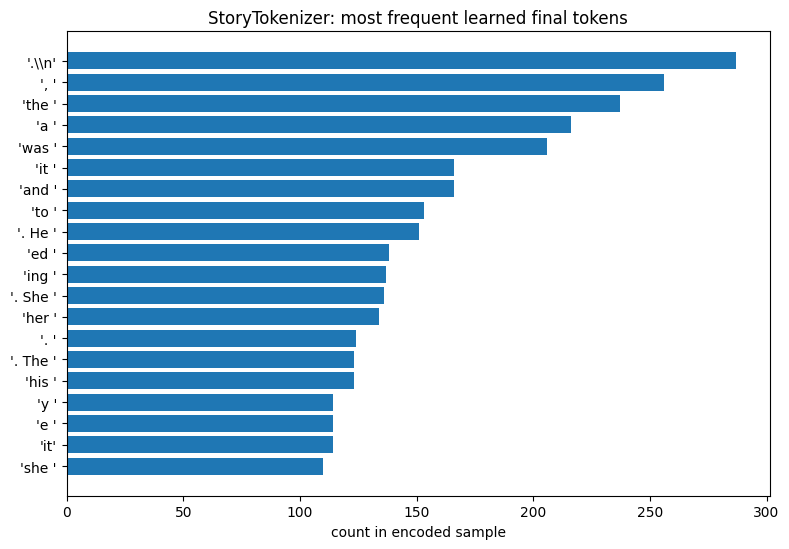

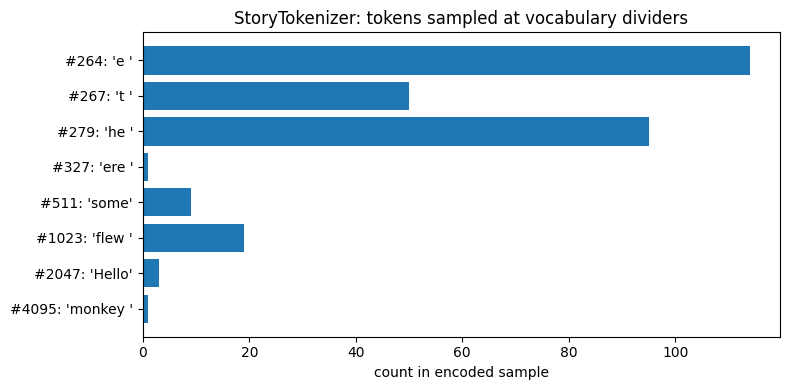

In [24]:
RUN_TINYSTORIES_TOKENIZER = True

story_config = TokenizerArtifactConfig(
    name="StoryTokenizer",
    source="tinystories",
    vocab_size=4096,
    max_chars=5_000_000,
    use_fast=True,
    chunk_chars=8_192,
    notes="TinyStories tokenizer for StoryLM. Increase max_chars when you want the durable artifact.",
)

story_artifact = run_and_inspect_tokenizer_artifact(
    story_config,
    repo_root=repo_root,
    enabled=RUN_TINYSTORIES_TOKENIZER,
    force=FORCE_RETRAIN_TOKENIZERS,
)

### G2C Corpus Tokenizer

The G2C corpus mixes course text with broader educational/code data for later TinyLLM experiments. It should also use `train_fast()`: the corpus is meant to be big enough that the Python teaching loop becomes the wrong tool for artifact generation.

Run `./datasets.sh --small` to create the small corpus first. The logical `g2c` source automatically uses the full corpus if it exists, otherwise it falls back to the small corpus.

loaded G2CTokenizer: 19,359,166 sample token IDs
G2CTokenizer
trainer: rust-tokenizers
vocab size: 16380
sample token count: 19359166
encoded sample chars: 99666113
chars/token: 5.148

Sample text:
'er to return our patients to their active lifestyle.\nIf you’re looking for compassionate, expert orthopedic and podiatric surgeons in Portland Oregon, contact OSM today.\n1515 NW 18th Ave, 3rd Floor\nPortland, OR 97209\n8:00am – 4:30pm\n<|endoftext|>\nFirefighter fatalities are devastating – for families, communities, and fellow emergency responders. The National'

Token strings for sample:
['er to ', 'return ', 'our ', 'patient', 's to ', 'their ', 'active ', 'lifesty', 'le', '.\\nIf ', 'you’re ', 'looking for ', 'compassion', 'ate, ', 'expert ', 'orth', 'op', 'ed', 'ic and ', 'po', 'di', 'atric ', 'surge', 'on', 's in ', 'Port', 'land ', 'O', 'reg', 'on, ', 'contact ', 'OS', 'M ', 'today', '.\\n', '15', '15 ', 'N', 'W ', '18', 'th ', 'A', 've, ', '3', 'r', 'd ', 'F', 'lo', 'or', '\\n', '

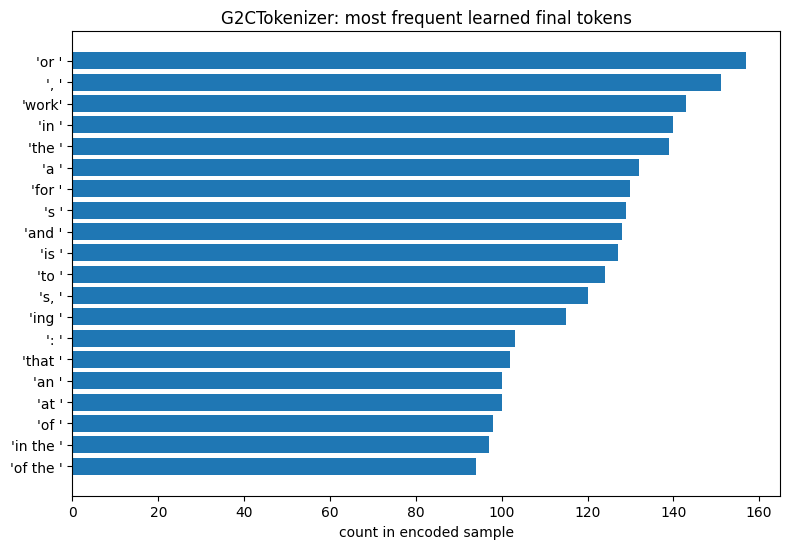

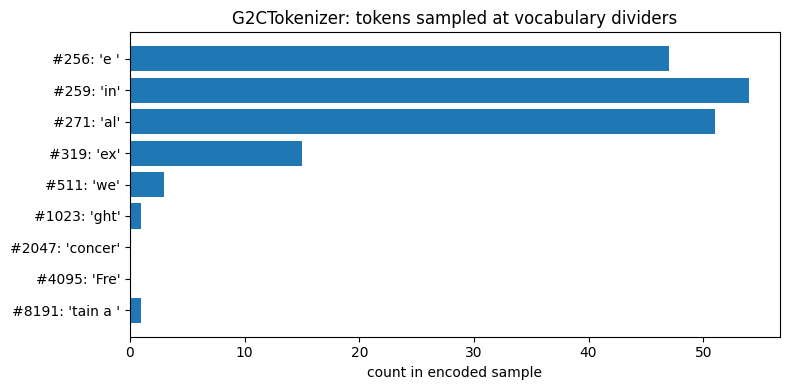

In [25]:
RUN_G2C_CORPUS_TOKENIZER = True

g2c_config = TokenizerArtifactConfig(
    name="G2CTokenizer",
    source="g2c",
    vocab_size=8192,
    max_chars=5_000_000,
    use_fast=True,
    chunk_chars=8_192,
    notes="Broad course-corpus tokenizer for TinyLLM-small experiments.",
)

g2c_artifact = run_and_inspect_tokenizer_artifact(
    g2c_config,
    repo_root=repo_root,
    enabled=RUN_G2C_CORPUS_TOKENIZER,
    force=FORCE_RETRAIN_TOKENIZERS,
)

## Submission Notes

When complete, ask a coding agent to grade your Module 04 notebook. Partial work is fine: the agent should grade answered questions and implemented sections, then skip blank prompts.